# FER-2013 YOLO + CNN Hybrid Emotion Recognition (v2, higher capacity)



In [ ]:
import os
import json
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
from google.colab import drive
from google.colab import files

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/EmD")
LOCAL_DIR = Path("/content/fer2013")

CHECKPOINT_DIR = DRIVE_DIR / "yolo_cnn_v2_checkpoints"
LATEST_MODEL = CHECKPOINT_DIR / "latest.keras"
BEST_MODEL = CHECKPOINT_DIR / "best.keras"
STATE_PATH = CHECKPOINT_DIR / "training_state.json"
LOG_PATH = CHECKPOINT_DIR / "training_log.csv"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Drive folder:", DRIVE_DIR)
print("Checkpoint folder:", CHECKPOINT_DIR)

Mounted at /content/drive
Drive folder: /content/drive/MyDrive/EmD
Checkpoint folder: /content/drive/MyDrive/EmD/yolo_cnn_v2_checkpoints


In [ ]:
def find_dataset_root(base):
    base = Path(base)

    if (base / "train").is_dir() and (base / "test").is_dir():
        return base

    for train_dir in base.rglob("train"):
        parent = train_dir.parent
        if (parent / "test").is_dir():
            return parent

    return None


drive_root = find_dataset_root(DRIVE_DIR)

if drive_root is not None:
    DATA_ROOT = drive_root
    print("Using extracted dataset:", DATA_ROOT)
else:
    zip_files = list(DRIVE_DIR.glob("*.zip"))

    if not zip_files:
        raise FileNotFoundError(
            "No FER-2013 train/test folders or ZIP file found inside MyDrive/EmD."
        )

    preferred = [p for p in zip_files if "fer" in p.name.lower()]
    ZIP_PATH = preferred[0] if preferred else zip_files[0]

    if not (LOCAL_DIR / "train").is_dir():
        LOCAL_DIR.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(LOCAL_DIR)

    DATA_ROOT = find_dataset_root(LOCAL_DIR)

    if DATA_ROOT is None:
        raise FileNotFoundError("train and test folders were not found after extraction.")

    print("ZIP:", ZIP_PATH)
    print("Local dataset:", DATA_ROOT)

ZIP: /content/drive/MyDrive/EmD/FER-2013.zip
Local dataset: /content/fer2013


In [ ]:
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

class_names = sorted([
    p.name for p in TRAIN_DIR.iterdir()
    if p.is_dir()
])

def image_count(folder):
    return sum(
        1 for p in Path(folder).rglob("*")
        if p.is_file() and p.suffix.lower() in extensions
    )

rows = []
for name in class_names:
    rows.append({
        "emotion": name,
        "train": image_count(TRAIN_DIR / name),
        "test": image_count(TEST_DIR / name)
    })

counts_df = pd.DataFrame(rows)
display(counts_df)
print("Classes:", class_names)
print("Total train:", counts_df["train"].sum())
print("Total test:", counts_df["test"].sum())

,emotion,train,test
0,angry,3995,958
1,disgust,436,111
2,fear,4097,1024
3,happy,7215,1774
4,neutral,4965,1233
5,sad,4830,1247
6,surprise,3171,831


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total train: 28709
Total test: 7178


In [ ]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
VAL_SPLIT = 0.20

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


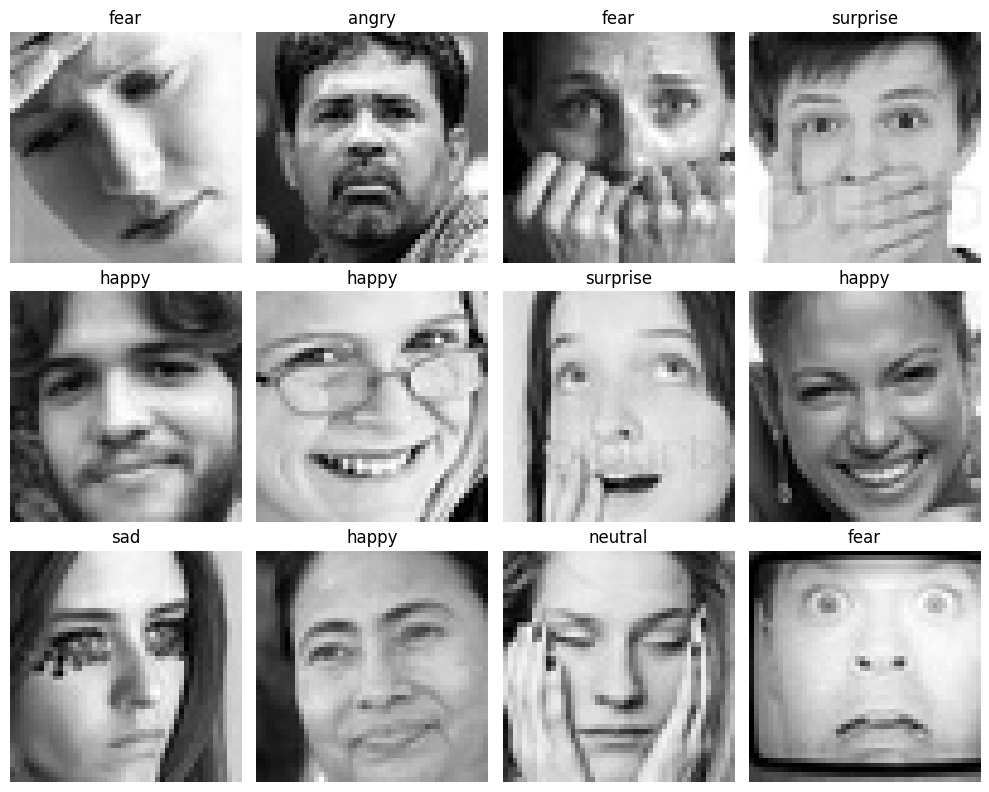

In [ ]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().squeeze(), cmap="gray")
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
train_counts = {
    name: image_count(TRAIN_DIR / name)
    for name in class_names
}

total_images = sum(train_counts.values())

class_weight = {
    i: total_images / (num_classes * train_counts[name])
    for i, name in enumerate(class_names)
}

print(class_weight)

{0: 1.0266046844269623, 1: 9.406618610747051, 2: 1.0010460615781582, 3: 0.5684387684387684, 4: 0.8260394187886635, 5: 0.8491274770777877, 6: 1.293372978330405}


## Full-frame bounding box annotation

FER-2013 has no bounding box labels, but every image is already a single tightly cropped face, so the entire frame is treated as the annotated face box: `objectness=1`, `x_center=0.5`, `y_center=0.5`, `width=1.0`, `height=1.0` in normalized coordinates. Class labels are one-hot encoded so the classification head can use label smoothing, and each sample carries a class-balanced weight.

In [ ]:
BBOX_TARGET = tf.constant([0.5, 0.5, 1.0, 1.0], dtype=tf.float32)

class_weight_array = tf.constant(
    [class_weight[i] for i in range(num_classes)],
    dtype=tf.float32
)

def add_yolo_targets(images, labels):
    batch_size = tf.shape(labels)[0]
    objectness = tf.ones((batch_size, 1), dtype=tf.float32)
    bbox = tf.tile(tf.expand_dims(BBOX_TARGET, 0), [batch_size, 1])
    detection_targets = tf.concat([objectness, bbox], axis=1)
    sample_weights = tf.gather(class_weight_array, labels)
    one_hot_labels = tf.one_hot(labels, depth=num_classes)
    targets = {"detection_output": detection_targets, "class_output": one_hot_labels}
    return images, targets, sample_weights

train_ds_multi = train_ds.map(add_yolo_targets, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_multi = val_ds.map(add_yolo_targets, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_multi = test_ds.map(add_yolo_targets, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

## Hybrid YOLO + CNN model

A deeper Darknet-style backbone (`Conv-BatchNorm-LeakyReLU` pairs up to 512 filters, each stage followed by a squeeze-and-excitation channel-attention block) feeds two heads from the same pooled features: a small YOLO-style detection head predicting `[objectness, x, y, w, h]` for the single full-frame box, and a two-layer CNN classification head predicting the emotion with label smoothing. Both heads train jointly with a weighted multi-task loss, and the optimizer uses decoupled weight decay.

In [ ]:
def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(negative_slope=0.1)(x)
    return x

def se_block(x, filters, ratio=8):
    se = tf.keras.layers.GlobalAveragePooling2D()(x)
    se = tf.keras.layers.Dense(max(filters // ratio, 8), activation="relu")(se)
    se = tf.keras.layers.Dense(filters, activation="sigmoid")(se)
    se = tf.keras.layers.Reshape((1, 1, filters))(se)
    return tf.keras.layers.Multiply()([x, se])

def build_model(num_classes):
    inputs = tf.keras.layers.Input(shape=(48, 48, 1))

    x = tf.keras.layers.RandomFlip("horizontal")(inputs)
    x = tf.keras.layers.RandomRotation(0.06)(x)
    x = tf.keras.layers.RandomTranslation(0.05, 0.05)(x)
    x = tf.keras.layers.RandomZoom(0.10)(x)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    x = conv_block(x, 64)
    x = conv_block(x, 64)
    x = se_block(x, 64)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = conv_block(x, 128)
    x = conv_block(x, 128)
    x = se_block(x, 128)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = conv_block(x, 256)
    x = conv_block(x, 256)
    x = se_block(x, 256)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = conv_block(x, 512)
    x = conv_block(x, 512)
    x = se_block(x, 512)
    x = tf.keras.layers.MaxPooling2D()(x)

    backbone_features = tf.keras.layers.GlobalAveragePooling2D()(x)

    d = tf.keras.layers.Dense(64)(backbone_features)
    d = tf.keras.layers.LeakyReLU(negative_slope=0.1)(d)
    detection_output = tf.keras.layers.Dense(5, activation="sigmoid", name="detection_output")(d)

    c = tf.keras.layers.Dropout(0.35)(backbone_features)
    c = tf.keras.layers.Dense(512)(c)
    c = tf.keras.layers.BatchNormalization()(c)
    c = tf.keras.layers.ReLU()(c)
    c = tf.keras.layers.Dropout(0.40)(c)
    c = tf.keras.layers.Dense(256)(c)
    c = tf.keras.layers.BatchNormalization()(c)
    c = tf.keras.layers.ReLU()(c)
    c = tf.keras.layers.Dropout(0.30)(c)
    class_output = tf.keras.layers.Dense(num_classes, activation="softmax", name="class_output")(c)

    model = tf.keras.Model(inputs=inputs, outputs=[detection_output, class_output])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, weight_decay=1e-4),
        loss={
            "detection_output": tf.keras.losses.MeanSquaredError(),
            "class_output": tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
        },
        loss_weights={
            "detection_output": 0.3,
            "class_output": 1.0
        },
        metrics={
            "class_output": "accuracy"
        }
    )

    return model

model = build_model(num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 48, 48, 1) │          0 │ input_layer[0][0] │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 48, 48, 1) │          0 │ random_flip[0][0] │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 48, 48, 1) │          0 │ random_rotation[… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 48, 48, 1) │          0 │ random_translati… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 48, 48, 1) │          0 │ random_zoom[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        576 │ rescaling[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │     36,864 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ leaky_re_lu_1[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 48, 48,    │          0 │ leaky_re_lu_1[0]… │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ multiply[0][0]  

 Total params: 5,210,116 (19.88 MB)

 Trainable params: 5,204,740 (19.85 MB)

 Non-trainable params: 5,376 (21.00 KB)

## Resume setup

If Colab disconnects, reconnect and run the notebook again. It loads `latest.keras` and continues from the last completed epoch.

In [ ]:
start_epoch = 0

if LATEST_MODEL.exists():
    model = tf.keras.models.load_model(LATEST_MODEL)

    if STATE_PATH.exists():
        with open(STATE_PATH, "r") as f:
            state = json.load(f)
        start_epoch = int(state.get("completed_epochs", 0))

    print(f"Loaded checkpoint. Resuming from epoch {start_epoch}.")
else:
    print("No checkpoint found. Starting fresh.")

No checkpoint found. Starting fresh.


In [ ]:
class EpochState(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        with open(STATE_PATH, "w") as f:
            json.dump({"completed_epochs": epoch + 1}, f)


latest_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(LATEST_MODEL),
    save_best_only=False,
    save_freq="epoch",
    verbose=1
)

best_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL),
    monitor="val_class_output_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

if LOG_PATH.exists():
    old_log = pd.read_csv(LOG_PATH)
    if "val_class_output_accuracy" in old_log and len(old_log):
        best_checkpoint.best = float(old_log["val_class_output_accuracy"].max())

callbacks = [
    latest_checkpoint,
    best_checkpoint,
    tf.keras.callbacks.CSVLogger(
        str(LOG_PATH),
        append=start_epoch > 0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_class_output_loss",
        mode="min",
        factor=0.5,
        patience=6,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_class_output_accuracy",
        mode="max",
        patience=18,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    EpochState()
]

In [ ]:
TOTAL_EPOCHS = 150

if start_epoch < TOTAL_EPOCHS:
    history = model.fit(
        train_ds_multi,
        validation_data=val_ds_multi,
        epochs=TOTAL_EPOCHS,
        initial_epoch=start_epoch,
        callbacks=callbacks
    )
else:
    print(
        f"Training already reached {start_epoch} epochs. "
        "Increase TOTAL_EPOCHS to continue training."
    )

Epoch 1/150
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - class_output_accuracy: 0.1482 - class_output_loss: 2.1297 - detection_output_loss: 0.0077 - loss: 2.1320
Epoch 1: saving model to /content/drive/MyDrive/EmD/yolo_cnn_v2_checkpoints/latest.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EmD/yolo_cnn_v2_checkpoints/latest.keras

Epoch 1: val_class_output_accuracy improved from None to 0.16792, saving model to /content/drive/MyDrive/EmD/yolo_cnn_v2_checkpoints/best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EmD/yolo_cnn_v2_checkpoints/best.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 56s 102ms/step - class_output_accuracy: 0.1494 - class_output_loss: 2.0654 - detection_output_loss: 0.0021 - loss: 2.0662 - val_class_output_accuracy: 0.1679 - val_class_output_loss: 1.9208 - val_detection_output_loss: 4.7135e-05 - val_loss: 1.9204 - learning_rate: 0.0010
Epoch 2/150
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - class_output_accuracy: 0.1620 - class_output_loss: 

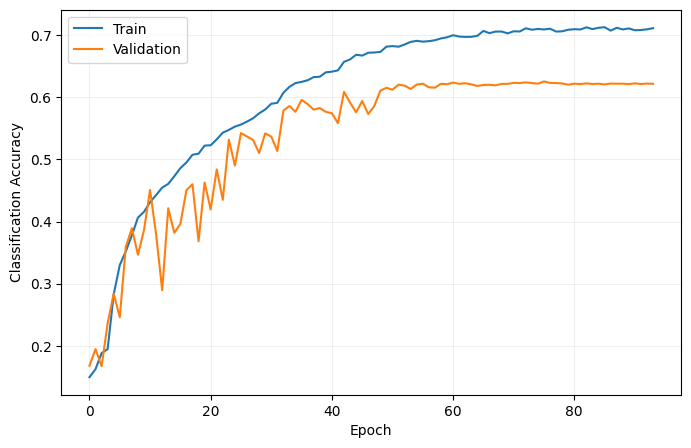

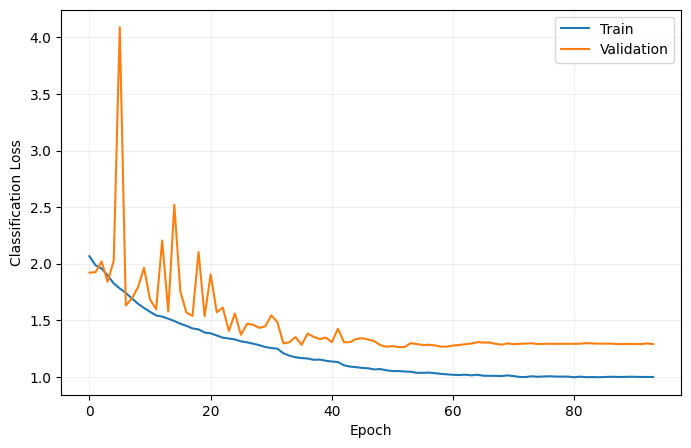

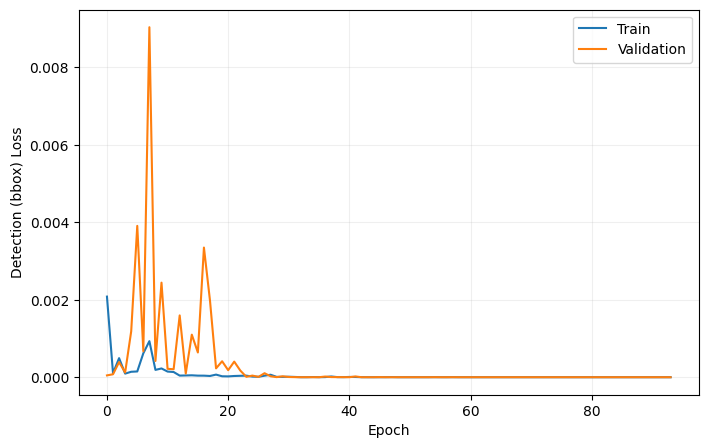

In [ ]:
if LOG_PATH.exists():
    log_df = pd.read_csv(LOG_PATH)

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["class_output_accuracy"], label="Train")
    plt.plot(log_df["val_class_output_accuracy"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Classification Accuracy")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["class_output_loss"], label="Train")
    plt.plot(log_df["val_class_output_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Classification Loss")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["detection_output_loss"], label="Train")
    plt.plot(log_df["val_detection_output_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Detection (bbox) Loss")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

## Test the trained model

In [ ]:
model_path = BEST_MODEL if BEST_MODEL.exists() else LATEST_MODEL

if not model_path.exists():
    raise FileNotFoundError("Train the model first.")

test_model = tf.keras.models.load_model(model_path)

test_results = test_model.evaluate(test_ds_multi, verbose=1)

for name, value in zip(test_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - class_output_accuracy: 0.6297 - class_output_loss: 1.3258 - detection_output_loss: 1.4426e-08 - loss: 1.3289
loss: 1.3289
compile_metrics: 0.0000
detection_output_loss: 1.3258
class_output_loss: 0.6297


In [ ]:
y_true = np.concatenate([
    np.argmax(targets["class_output"].numpy(), axis=1)
    for _, targets, _ in test_ds_multi
])

y_detection_pred, y_prob = test_model.predict(test_ds_multi, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
              precision    recall  f1-score   support

       angry     0.5127    0.5898    0.5485       958
     disgust     0.6132    0.5856    0.5991       111
        fear     0.4622    0.3760    0.4146      1024
       happy     0.8896    0.8264    0.8568      1774
     neutral     0.5844    0.6148    0.5992      1233
         sad     0.4919    0.5333    0.5117      1247
    surprise     0.7333    0.7413    0.7373       831

    accuracy                         0.6297      7178
   macro avg     0.6125    0.6096    0.6096      7178
weighted avg     0.6344    0.6297    0.6306      7178



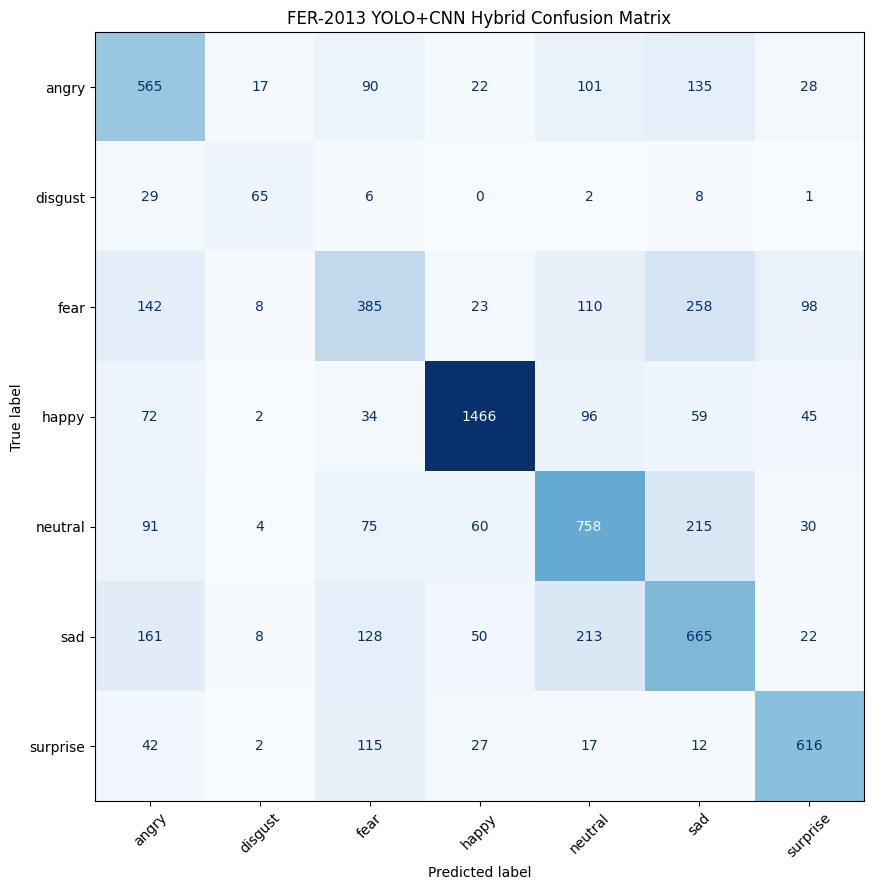

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.xticks(rotation=45)
plt.title("FER-2013 YOLO+CNN Hybrid Confusion Matrix")
plt.tight_layout()
plt.show()

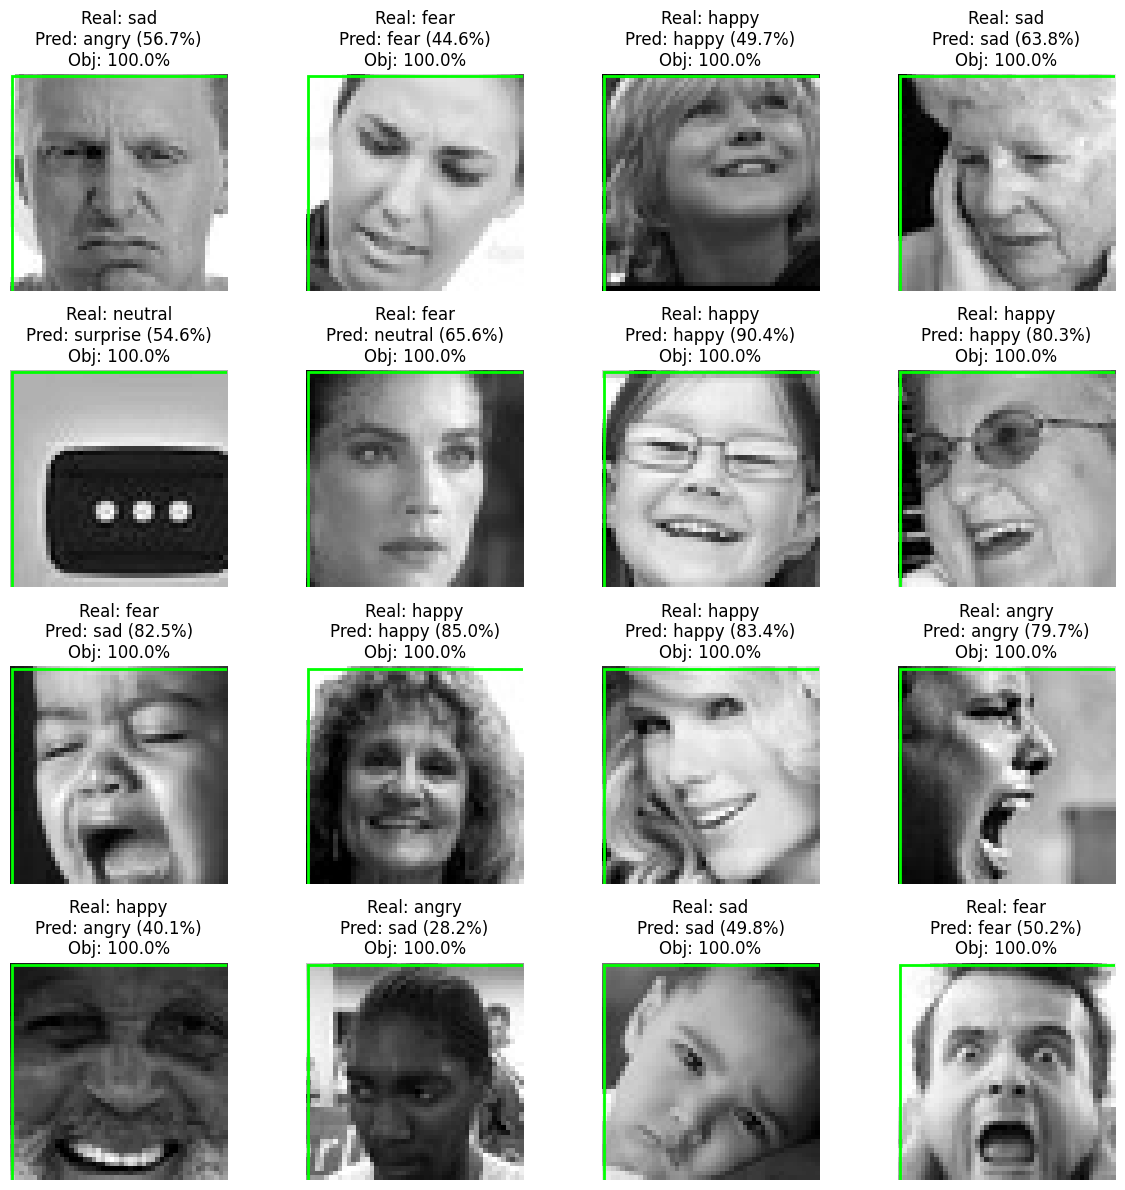

In [ ]:
num_test_images = int(counts_df["test"].sum())

sample_ds = (
    test_ds_multi
    .unbatch()
    .shuffle(
        buffer_size=num_test_images,
        reshuffle_each_iteration=True
    )
    .take(16)
    .batch(16)
)

sample_images, sample_targets, _ = next(iter(sample_ds))
sample_labels = np.argmax(sample_targets["class_output"].numpy(), axis=1)

sample_detection_pred, sample_probs = test_model.predict(
    sample_images,
    verbose=0
)

sample_preds = np.argmax(sample_probs, axis=1)

img_size = IMG_SIZE[0]

plt.figure(figsize=(12, 12))

for i in range(len(sample_images)):
    real_label = class_names[int(sample_labels[i])]
    predicted_label = class_names[int(sample_preds[i])]
    confidence = float(np.max(sample_probs[i])) * 100
    objectness = float(sample_detection_pred[i][0]) * 100

    x_c, y_c, w, h = sample_detection_pred[i][1:]
    x1 = (x_c - w / 2) * img_size
    y1 = (y_c - h / 2) * img_size

    ax = plt.subplot(4, 4, i + 1)

    plt.imshow(
        sample_images[i].numpy().squeeze(),
        cmap="gray"
    )

    rect = patches.Rectangle(
        (x1, y1),
        w * img_size,
        h * img_size,
        linewidth=2,
        edgecolor="lime",
        facecolor="none"
    )
    ax.add_patch(rect)

    plt.title(
        f"Real: {real_label}\n"
        f"Pred: {predicted_label} ({confidence:.1f}%)\n"
        f"Obj: {objectness:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()